# Predicting Real-World Arm Use After Stroke

**Author:** Asad NADEEM  
**Course:** Python-R-Git  
**Program:** Master STAPS — Sciences Technologies Mouvement  
**Lab:** EuroMov Digital Health in Motion — University of Montpellier  
**Supervisors:** Karima BAKHTI, Makii MUTHALIB, Nicolas SUTTON-CHARANI  

**GitHub:** https://github.com/asadazizmughal/predicting-arm-use-stroke

---

## Scientific Question

Can clinical motor and functional tests predict how much stroke patients actually use their paretic (weak) arm in daily life at home?

## Notebook overview

1. **Setup** — import libraries, create output folder
2. **Load clinical data** — 30 patients with FMUE, WMFT, BBT, Barthel, PANU scores
3. **Load accelerometry data** — 7-day wrist-worn sensor counts
4. **Compute funcUseRatio** — target variable
5. **Merge datasets**
6. **LOOCV modeling** with in-fold imputation (Prof. Dray's recommendation)
7. **Compare models** — Linear Regression, Ridge, Lasso
8. **Feature importance & discrepancy analysis**

---

## 1. Setup

We import all libraries we will use throughout the notebook and set plot styles. The `results/` folder is created automatically if it doesn't exist — this makes the project portable (works on any computer).

In [1]:
# Library imports for the full ML pipeline
# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# File handling
import openpyxl
import os

# Machine learning (scikit-learn)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.base import clone

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Make sure results folder exists
os.makedirs('results', exist_ok=True)

print("Setup complete — libraries loaded, results folder ready.")

Setup complete — libraries loaded, results folder ready.


## 2. Load Clinical Data

The clinical data comes from the **ReArm protocol** (Muller et al., 2021), a randomized controlled trial at CHU Montpellier. Thirty post-stroke patients were assessed with standardized clinical tests.

We use `openpyxl` (cell-by-cell reading) rather than `pandas.read_excel` because the file has header formatting issues (extra spaces, merged cells) that cause pandas to misread columns.

**Variables loaded:**

- `SUBJID` — patient identifier
- `Sex`, `Age`, `Paresis` — demographic and clinical info
- `PANU` — Proximal Arm Non-Use (%)
- `Barthel` — Barthel Index of daily living independence (/100)
- `FMUE_TOTAL` — Fugl-Meyer Upper Extremity (/66)
- `WMFT_Total` — Wolf Motor Function Test (/75)
- `BBT_P` — Box & Block Test, paretic hand

In [2]:
# Open the Excel workbook
workbook = openpyxl.load_workbook('data/Outcomes_Rearm_01_04_23.xlsx')
sheet = workbook['V1']  # The file has only one sheet

# Read each row into a dictionary, then build a DataFrame
clinical_rows = []
for row_idx in range(2, sheet.max_row + 1):   # row 1 is headers, so start at row 2
    clinical_rows.append({
        'SUBJID':      sheet.cell(row_idx, 1).value,
        'Sex':         sheet.cell(row_idx, 3).value,
        'Age':         sheet.cell(row_idx, 4).value,
        'Paresis':     sheet.cell(row_idx, 6).value,
        'PANU':        sheet.cell(row_idx, 7).value,
        'Barthel':     sheet.cell(row_idx, 8).value,
        'FMUE_TOTAL':  sheet.cell(row_idx, 11).value,
        'WMFT_Total':  sheet.cell(row_idx, 12).value,
        'BBT_P':       sheet.cell(row_idx, 17).value,
    })

clinical_df = pd.DataFrame(clinical_rows)

# Standardize the patient ID so it matches the accelerometry file
# Clinical file uses 'C1-P01', accelerometry uses 'C1P01'
clinical_df['ID'] = clinical_df['SUBJID'].str.replace('-', '')

# Quick check
print(f"Clinical data loaded: {len(clinical_df)} patients")
clinical_df.head()

Clinical data loaded: 30 patients


,SUBJID,Sex,Age,Paresis,PANU,Barthel,FMUE_TOTAL,WMFT_Total,BBT_P,ID
0,C1-P01,Homme,63,Droite,3.0,85.0,45,64,38,C1P01
1,C1-P02,Homme,49,Gauche,3.0,100.0,65,73,52,C1P02
2,C1-P03,Homme,59,Gauche,2.0,90.0,48,56,11,C1P03
3,C1-P04,Homme,61,Gauche,1.0,95.0,60,62,27,C1P04
4,C1-P05,Homme,52,Gauche,3.0,90.0,57,57,15,C1P05


## 3. Load Accelerometry Data

Patients wore **accelerometers on both wrists** for 7 days at home. For each day and each arm, the data contains a count of *functional movements* computed with the algorithm from Leuenberger et al. (2017):

- Forearm amplitude > 30°
- Within ±30° of horizontal  
- In 2-second non-overlapping windows

This filters out passive movements like arm swinging during walking.

The file uses `;` as separator (European CSV convention). For each patient we have 21 daily columns: 7 days × 3 arms (Paretic, Non-Paretic, Bilateral).

In [3]:
# Read accelerometry CSV (semicolon separator — European format)
accel_df = pd.read_csv('data/all_day_FuncUse_uni_bi.csv', sep=';')

print(f"Accelerometry data loaded: {len(accel_df)} patients")
print(f"Number of columns: {accel_df.shape[1]}")

# Check missing values
missing_counts = accel_df.isnull().sum()
print(f"\nColumns with missing values:")
print(missing_counts[missing_counts > 0].to_string())

accel_df.head()

Accelerometry data loaded: 30 patients
Number of columns: 22

Columns with missing values:
Non_Paretic_Day5    1
Paretic_Day5        1
Bilat_Day5          1
Non_Paretic_Day6    1
Paretic_Day6        1
Bilat_Day6          1
Non_Paretic_Day7    3
Paretic_Day7        3
Bilat_Day7          3


,ID,Non_Paretic_Day1,Paretic_Day1,Bilat_Day1,Non_Paretic_Day2,Paretic_Day2,Bilat_Day2,Non_Paretic_Day3,Paretic_Day3,Bilat_Day3,...,Bilat_Day4,Non_Paretic_Day5,Paretic_Day5,Bilat_Day5,Non_Paretic_Day6,Paretic_Day6,Bilat_Day6,Non_Paretic_Day7,Paretic_Day7,Bilat_Day7
0,C1P01,2599,2777,1366,2567,2349,874,3737,3737,1437,...,1293,2780.0,2582.0,988.0,2821.0,3119.0,1027.0,2513.0,2849.0,800.0
1,C1P02,3562,1525,1001,3817,1675,889,3329,1247,573,...,514,3273.0,1480.0,641.0,2725.0,959.0,542.0,3353.0,1086.0,589.0
2,C1P03,4108,306,77,3835,410,85,6198,399,160,...,209,4936.0,227.0,70.0,6751.0,417.0,290.0,5712.0,285.0,101.0
3,C1P04,2055,498,98,3462,510,240,2738,416,97,...,164,3553.0,473.0,181.0,2912.0,549.0,128.0,3232.0,637.0,199.0
4,C1P05,1243,211,137,5050,679,333,6065,806,278,...,275,5048.0,707.0,392.0,5175.0,496.0,409.0,5273.0,592.0,428.0


## 4. Compute funcUseRatio (Target Variable)

Our target variable measures real-world arm use:

$$\text{funcUseRatio} = \frac{\overline{\text{FuncUse}}_{\text{paretic}}}{\overline{\text{FuncUse}}_{\text{non-paretic}}}$$

Where the means are computed across the 7 days. Interpretation:

- Ratio ≈ 1.0 → both arms used equally
- Ratio ≈ 0.25 → paretic arm used 4× less
- Ratio > 1.0 → paretic arm used MORE (unusual, possibly outlier)

**Rule for valid days:** we only include days where both arm counts exist and the non-paretic count is > 0 (to avoid division by zero).

In [4]:
# Compute funcUseRatio for each patient
func_use_list = []

for _, row in accel_df.iterrows():
    paretic_counts = []
    non_paretic_counts = []
    
    # Loop through 7 days
    for day in range(1, 8):
        paretic_day = row[f'Paretic_Day{day}']
        non_paretic_day = row[f'Non_Paretic_Day{day}']
        
        # Keep only valid days (both values exist, non-paretic > 0)
        if pd.notna(paretic_day) and pd.notna(non_paretic_day) and non_paretic_day > 0:
            paretic_counts.append(paretic_day)
            non_paretic_counts.append(non_paretic_day)
    
    # Use numpy for the mean and ratio calculation
    mean_paretic = np.mean(paretic_counts)
    mean_non_paretic = np.mean(non_paretic_counts)
    func_use_ratio = mean_paretic / mean_non_paretic
    
    func_use_list.append({
        'ID': row['ID'],
        'funcUseRatio': round(func_use_ratio, 4),
        'valid_days': len(paretic_counts),
    })

accel_summary_df = pd.DataFrame(func_use_list)

print(f"funcUseRatio computed for {len(accel_summary_df)} patients")
print(f"Valid days: min = {accel_summary_df['valid_days'].min()}, "
      f"max = {accel_summary_df['valid_days'].max()}, "
      f"mean = {accel_summary_df['valid_days'].mean():.1f}")
print(f"\nfuncUseRatio statistics:")
print(accel_summary_df['funcUseRatio'].describe().round(3).to_string())

accel_summary_df

funcUseRatio computed for 30 patients
Valid days: min = 4, max = 7, mean = 6.8

funcUseRatio statistics:
count    30.000
mean      0.246
std       0.217
min       0.030
25%       0.088
50%       0.183
75%       0.342
max       1.026


,ID,funcUseRatio,valid_days
0,C1P01,1.0257,7
1,C1P02,0.3936,7
2,C1P03,0.0669,7
3,C1P04,0.1780,7
4,C1P05,0.1277,7
5,C1P07,0.1752,7
6,C1P08,0.1882,6
7,C1P09,0.3324,7
8,C1P10,0.0843,7
9,C1P11,0.5403,7


## 5. Merge Clinical + Accelerometry Data

We combine the two DataFrames on the patient ID. Using `how='inner'` keeps only patients present in **both** datasets. Since both have 30 patients, we expect 30 rows after the merge.

In [5]:
# Inner merge: keep only patients in both datasets
merged_df = clinical_df.merge(accel_summary_df, on='ID', how='inner')

print(f"Merged dataset: {len(merged_df)} patients")
print(f"Columns: {list(merged_df.columns)}")

# Display the merged table
merged_df[['ID', 'Sex', 'Age', 'Paresis', 'PANU', 'Barthel',
           'FMUE_TOTAL', 'WMFT_Total', 'BBT_P', 'funcUseRatio']]

Merged dataset: 30 patients
Columns: ['SUBJID', 'Sex', 'Age', 'Paresis', 'PANU', 'Barthel', 'FMUE_TOTAL', 'WMFT_Total', 'BBT_P', 'ID', 'funcUseRatio', 'valid_days']


,ID,Sex,Age,Paresis,PANU,Barthel,FMUE_TOTAL,WMFT_Total,BBT_P,funcUseRatio
0,C1P01,Homme,63,Droite,3.0,85.0,45,64,38,1.0257
1,C1P02,Homme,49,Gauche,3.0,100.0,65,73,52,0.3936
2,C1P03,Homme,59,Gauche,2.0,90.0,48,56,11,0.0669
3,C1P04,Homme,61,Gauche,1.0,95.0,60,62,27,0.1780
4,C1P05,Homme,52,Gauche,3.0,90.0,57,57,15,0.1277
5,C1P07,Homme,71,Gauche,7.0,100.0,59,72,45,0.1752
6,C1P08,Femme,33,Droite,7.0,100.0,53,63,39,0.1882
7,C1P09,Femme,73,Gauche,1.0,95.0,61,75,47,0.3324
8,C1P10,Homme,65,Gauche,1.0,90.0,29,36,6,0.0843
9,C1P11,Femme,57,Gauche,3.0,90.0,66,75,57,0.5403


## 6. Missing Values

Before modeling, we check which variables have missing values:

- **< 15% missing** → impute with the median (robust to outliers)
- **> 40% missing** → drop the variable entirely

Note: imputation happens *inside each LOOCV fold* in Step 9, not here. In this cell we only report the pattern of missingness.

In [6]:
# Define our features and target
feature_names = ['PANU', 'FMUE_TOTAL', 'WMFT_Total', 'BBT_P', 'Barthel', 'Age']
target_name = 'funcUseRatio'

print("=== Missing Values Report ===\n")
for column in feature_names + [target_name]:
    n_missing = merged_df[column].isnull().sum()
    pct_missing = n_missing / len(merged_df) * 100
    
    if n_missing > 0:
        affected_patients = merged_df[merged_df[column].isnull()]['ID'].tolist()
        print(f"{column:15s}: {n_missing} missing ({pct_missing:.0f}%) → {affected_patients}")
    else:
        print(f"{column:15s}: 0 missing OK")

print("\nDecision: PANU and Barthel imputed with median INSIDE each LOOCV fold")

=== Missing Values Report ===

PANU           : 3 missing (10%) → ['C1P26', 'C2P08', 'C2P09']
FMUE_TOTAL     : 0 missing OK
WMFT_Total     : 0 missing OK
BBT_P          : 0 missing OK
Barthel        : 2 missing (7%) → ['C2P08', 'C2P09']
Age            : 0 missing OK
funcUseRatio   : 0 missing OK

Decision: PANU and Barthel imputed with median INSIDE each LOOCV fold


## 7. Encode Categorical Variables

Machine learning models work with numbers, not text. We convert `Sex` and `Paresis` to binary variables:

- `Sex_encoded`: 1 if `Homme` (male), 0 if `Femme` (female)
- `Paresis_left`: 1 if left side paretic, 0 if right side

In [7]:
# Binary encoding
merged_df['Sex_encoded'] = (merged_df['Sex'] == 'Homme').astype(int)
merged_df['Paresis_left'] = (merged_df['Paresis'] == 'Gauche').astype(int)

print(f"Sex: {merged_df['Sex_encoded'].value_counts().to_dict()} (1 = Homme, 0 = Femme)")
print(f"Paresis: {merged_df['Paresis_left'].value_counts().to_dict()} (1 = Gauche, 0 = Droite)")

# Full feature list including encoded categorical
all_feature_names = feature_names + ['Sex_encoded', 'Paresis_left']
print(f"\nAll features for modeling: {all_feature_names}")

Sex: {1: 21, 0: 9} (1 = Homme, 0 = Femme)
Paresis: {1: 17, 0: 13} (1 = Gauche, 0 = Droite)

All features for modeling: ['PANU', 'FMUE_TOTAL', 'WMFT_Total', 'BBT_P', 'Barthel', 'Age', 'Sex_encoded', 'Paresis_left']


## 8. Save Merged Dataset for R Analysis

We save the merged dataset as a CSV so the R notebook (`main.Rmd`) can load it directly without redoing the merge. This keeps the pipeline clean — each notebook has one responsibility.

In [8]:
# Save the full merged dataset
output_columns = ['ID', 'Sex', 'Age', 'Paresis',
                  'PANU', 'Barthel', 'FMUE_TOTAL', 'WMFT_Total', 'BBT_P',
                  'funcUseRatio', 'valid_days',
                  'Sex_encoded', 'Paresis_left']

merged_df[output_columns].to_csv('data/merged_dataset.csv', index=False)
print(f"Saved: data/merged_dataset.csv ({len(merged_df)} rows, {len(output_columns)} columns)")

Saved: data/merged_dataset.csv (30 rows, 13 columns)


## 9. LOOCV Modeling Pipeline

### Why LOOCV?

With only 30 patients, a standard train/test split leaves too few patients for reliable evaluation. **Leave-One-Out Cross-Validation** (LOOCV) trains on 29 patients and predicts the 1 left-out patient, rotating 30 times so every patient gets exactly one prediction.

### Why in-fold imputation?

Prof. Gérard Dray (IMT Mines Alès) emphasized that imputation must happen *inside each fold* to prevent **data leakage**. Computing the median on all 30 patients and then testing on patient 1 means the median already "knows" patient 1's value.

### Inside each fold

1. Split: 29 train patients, 1 test patient
2. Compute median of each feature **from the 29 training patients**
3. Apply that median to impute missing values in both train and test
4. Fit `StandardScaler` on train only, transform both
5. Fit each model on train, predict test
6. Store prediction

### Models compared

- **Linear Regression** — baseline, no regularization
- **Ridge (α=1.0)** — L2 penalty, handles multicollinearity
- **Lasso (α=0.01)** — L1 penalty, does automatic feature selection

In [9]:
# Prepare arrays for modeling
features_matrix = merged_df[all_feature_names].copy()     # predictors (with missing values still in)
target_array = merged_df[target_name].to_numpy()           # target (funcUseRatio)
patient_ids = merged_df['ID'].to_numpy()
n_patients = len(target_array)

print(f"Dataset: {n_patients} patients, {len(all_feature_names)} features")

# Define the models to compare
models = {
    'Linear Regression':   LinearRegression(),
    'Ridge (alpha=1.0)':   Ridge(alpha=1.0),
    'Lasso (alpha=0.01)':  Lasso(alpha=0.01, max_iter=10000),
}

# Storage for each model's true/predicted values across all folds
results = {name: {'y_true': [], 'y_pred': []} for name in models}

# Store Lasso coefficients from each fold (for feature importance later)
lasso_coefficients_per_fold = []

# Run the LOOCV loop
loo = LeaveOneOut()

for fold_idx, (train_idx, test_idx) in enumerate(loo.split(features_matrix)):
    # Split the data
    X_train_raw = features_matrix.iloc[train_idx].copy()
    X_test_raw = features_matrix.iloc[test_idx].copy()
    y_train = target_array[train_idx]
    y_test = target_array[test_idx]
    
    # IN-FOLD IMPUTATION (Prof. Dray's requirement)
    # Compute median on training patients ONLY
    for col in feature_names:   # only continuous features have missing values
        train_median = X_train_raw[col].median()
        X_train_raw.loc[:, col] = X_train_raw[col].fillna(train_median)
        X_test_raw.loc[:, col] = X_test_raw[col].fillna(train_median)
    
    # STANDARDIZATION — fit on train only, transform both
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)
    
    # Fit each model and make predictions
    for model_name, base_model in models.items():
        model = clone(base_model)   # fresh copy for each fold
        model.fit(X_train_scaled, y_train)
        prediction = model.predict(X_test_scaled)
        
        results[model_name]['y_true'].append(y_test[0])
        results[model_name]['y_pred'].append(prediction[0])
        
        # Save Lasso coefficients for feature importance
        if 'Lasso' in model_name:
            lasso_coefficients_per_fold.append(model.coef_)

print(f"LOOCV complete: {n_patients} folds x {len(models)} models")

Dataset: 30 patients, 8 features
LOOCV complete: 30 folds x 3 models


## 10. Model Evaluation

We compare each model using three metrics:

- **MAE** (Mean Absolute Error): average prediction error in the same units as funcUseRatio
- **RMSE** (Root Mean Squared Error): like MAE but penalizes large errors more
- **CV R²** (Cross-Validated R²): fraction of variance explained
    - R² = 1 → perfect predictions
    - R² = 0 → model equivalent to always predicting the mean
    - R² < 0 → model *worse* than the mean

With only 30 patients, negative R² is a real possibility — it signals overfitting.

In [10]:
# Compute metrics for each model
metrics_list = []

for model_name in models:
    y_true_array = np.array(results[model_name]['y_true'])
    y_pred_array = np.array(results[model_name]['y_pred'])
    
    mae = mean_absolute_error(y_true_array, y_pred_array)
    rmse = np.sqrt(mean_squared_error(y_true_array, y_pred_array))
    
    # CV R^2 = 1 - (sum of squared errors / total variance)
    ss_residual = np.sum((y_true_array - y_pred_array) ** 2)
    ss_total = np.sum((y_true_array - np.mean(y_true_array)) ** 2)
    r2_cv = 1 - ss_residual / ss_total
    
    metrics_list.append({
        'Model': model_name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'CV_R2': round(r2_cv, 4),
    })

metrics_df = pd.DataFrame(metrics_list).sort_values('CV_R2', ascending=False)
print("Model ranking by CV R²:\n")
print(metrics_df.to_string(index=False))

# Save for the report
metrics_df.to_csv('results/model_metrics.csv', index=False)
print("\nSaved: results/model_metrics.csv")

Model ranking by CV R²:

             Model    MAE   RMSE   CV_R2
Lasso (alpha=0.01) 0.1619 0.2180 -0.0474
 Ridge (alpha=1.0) 0.1718 0.2261 -0.1266
 Linear Regression 0.1820 0.2328 -0.1936

Saved: results/model_metrics.csv


## 11. Predicted vs Actual Plot

For each model, we plot predicted vs actual funcUseRatio. Points on the red dashed line = perfect predictions. Spread around the line shows model error visually.

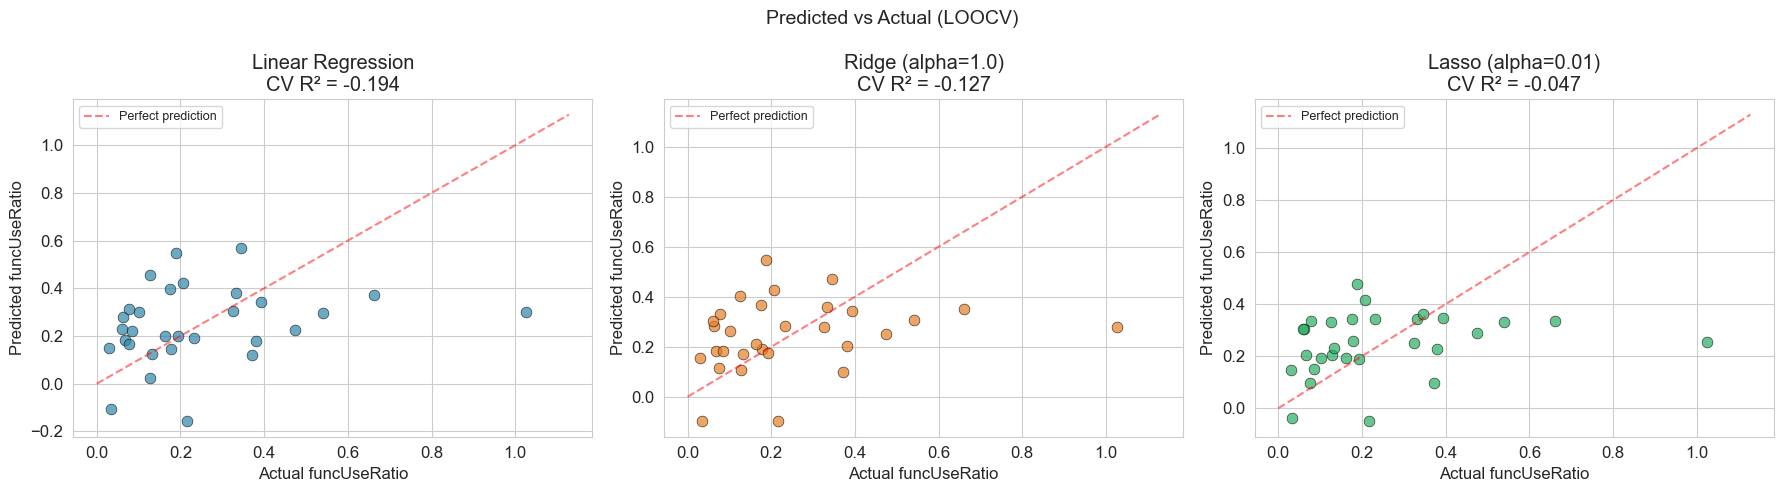

Saved: results/predicted_vs_actual.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_colors = ['#2E86AB', '#E67E22', '#27AE60']

for idx, (model_name, color) in enumerate(zip(models.keys(), plot_colors)):
    ax = axes[idx]
    y_true_array = np.array(results[model_name]['y_true'])
    y_pred_array = np.array(results[model_name]['y_pred'])
    
    ax.scatter(y_true_array, y_pred_array, alpha=0.7, s=60,
               color=color, edgecolors='black', linewidth=0.5)
    
    # Perfect prediction line (y = x)
    max_val = max(y_true_array.max(), y_pred_array.max()) * 1.1
    ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Perfect prediction')
    
    r2_value = metrics_df[metrics_df['Model'] == model_name]['CV_R2'].values[0]
    ax.set_xlabel('Actual funcUseRatio')
    ax.set_ylabel('Predicted funcUseRatio')
    ax.set_title(f'{model_name}\nCV R² = {r2_value:.3f}')
    ax.legend(fontsize=9)

plt.suptitle('Predicted vs Actual (LOOCV)', fontsize=14)
plt.tight_layout()
plt.savefig('results/predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/predicted_vs_actual.png")